In [45]:
import subprocess
subprocess.run(["pip", "install", "matplotlib"])


CompletedProcess(args=['pip', 'install', 'matplotlib'], returncode=0)

In [3]:
import pandas as pd

# df = pd.read_parquet("data/yellow_tripdata_2024-01.parquet")
df = pd.read_parquet(r"c:\Users\Таня\Desktop\Folder\Programming\uber\data\yellow_tripdata_2024-01.parquet")

print(df.shape)
print(df.dtypes)
print(df.head())

(2964624, 19)
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2024-01-01 00:57:55   2024-01-01 01:17:43              1.0   
1         1  2024-01-01 00:03:00   2024-01-01 00:09:36        

In [5]:
print(df["tpep_pickup_datetime"].min())
print(df["tpep_pickup_datetime"].max())
print(df["PULocationID"].nunique())
print(df.isnull().sum())

2002-12-31 22:59:39
2024-02-01 00:01:15
260
VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          140162
trip_distance                 0
RatecodeID               140162
store_and_fwd_flag       140162
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     140162
Airport_fee              140162
dtype: int64


In [21]:
bad = df[("tpep_pickup_datetime" < "2024-01-01") | (df["tpep_pickup_datetime"] >= "2024-02-01")]
print(bad.shape)


(0, 19)


In [24]:
print(df['trip_distance'].describe())
print(df['fare_amount'].describe())

count    2.964606e+06
mean     3.652170e+00
std      2.254633e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.680000e+00
75%      3.110000e+00
max      3.127223e+05
Name: trip_distance, dtype: float64
count    2.964606e+06
mean     1.817507e+01
std      1.894957e+01
min     -8.990000e+02
25%      8.600000e+00
50%      1.280000e+01
75%      2.050000e+01
max      5.000000e+03
Name: fare_amount, dtype: float64


In [26]:
print(df[df['trip_distance'] <= 0].shape[0] / df.shape[0])
print(df[df['fare_amount'] <= 0].shape[0] / df.shape[0])

0.020363920197152673
0.012932578561872977


In [27]:
df = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)]
print(df.shape[0])

2869697


In [28]:
df['pickup_hour'] = df["tpep_pickup_datetime"].dt.hour
df["pickup_dow"] = df['tpep_pickup_datetime'].dt.day_of_week
print(df[["tpep_pickup_datetime", "pickup_hour", "pickup_dow"]].head())

  tpep_pickup_datetime  pickup_hour  pickup_dow
0  2024-01-01 00:57:55            0           0
1  2024-01-01 00:03:00            0           0
2  2024-01-01 00:17:06            0           0
3  2024-01-01 00:36:38            0           0
4  2024-01-01 00:46:51            0           0


In [40]:
demand = df.groupby(["PULocationID", "pickup_hour", "pickup_dow"]).size().reset_index(name="trip_count")
print(demand.shape)

(25322, 4)


In [43]:
print(demand.tail(10))
print(demand["trip_count"].describe())

       PULocationID  pickup_hour  pickup_dow  trip_count
25312           265           22           4           2
25313           265           22           5           1
25314           265           22           6           2
25315           265           23           0           5
25316           265           23           1           4
25317           265           23           2           5
25318           265           23           3           2
25319           265           23           4           2
25320           265           23           5           1
25321           265           23           6           6
count    25322.000000
mean       113.328213
std        258.061314
min          1.000000
25%          2.000000
50%          5.000000
75%         69.000000
max       2916.000000
Name: trip_count, dtype: float64


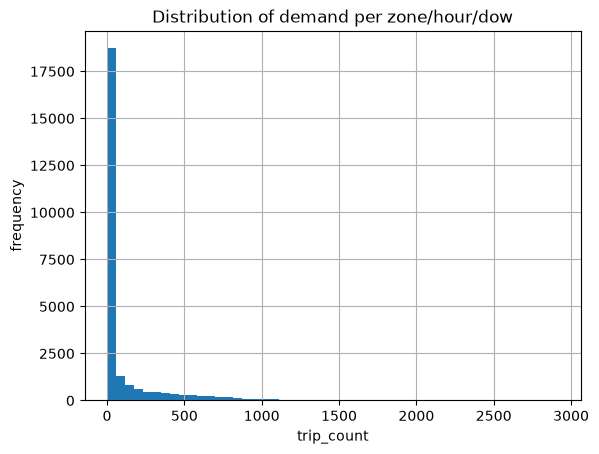

In [48]:
import matplotlib.pyplot as plt

demand["trip_count"].hist(bins=50)
plt.xlabel("trip_count")
plt.ylabel("frequency")
plt.title("Distribution of demand per zone/hour/dow")
plt.show()


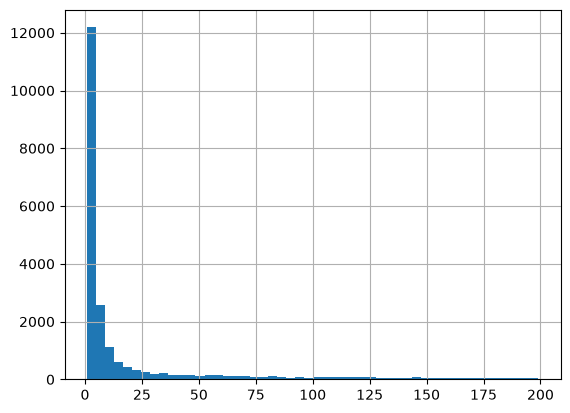

In [49]:
demand[demand["trip_count"] < 200]["trip_count"].hist(bins=50)
plt.show()

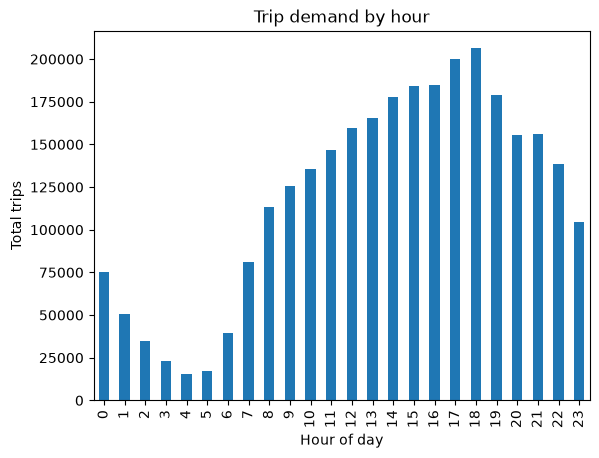

In [50]:
hourly = df.groupby("pickup_hour").size()
hourly.plot(kind="bar")
plt.xlabel("Hour of day")
plt.ylabel("Total trips")
plt.title("Trip demand by hour")
plt.show()


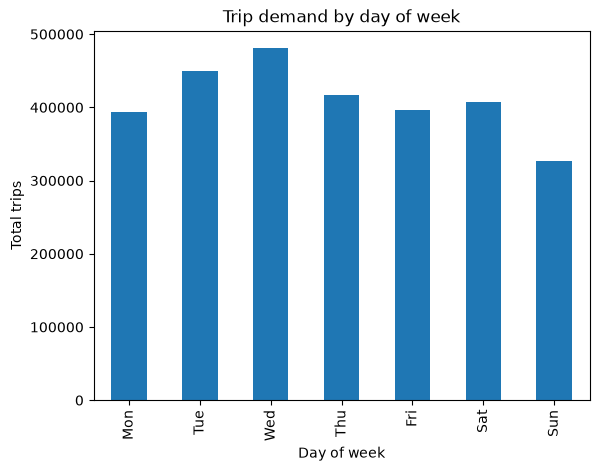

In [51]:
daily = df.groupby("pickup_dow").size()
daily.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily.plot(kind="bar")
plt.xlabel("Day of week")
plt.ylabel("Total trips")
plt.title("Trip demand by day of week")
plt.show()


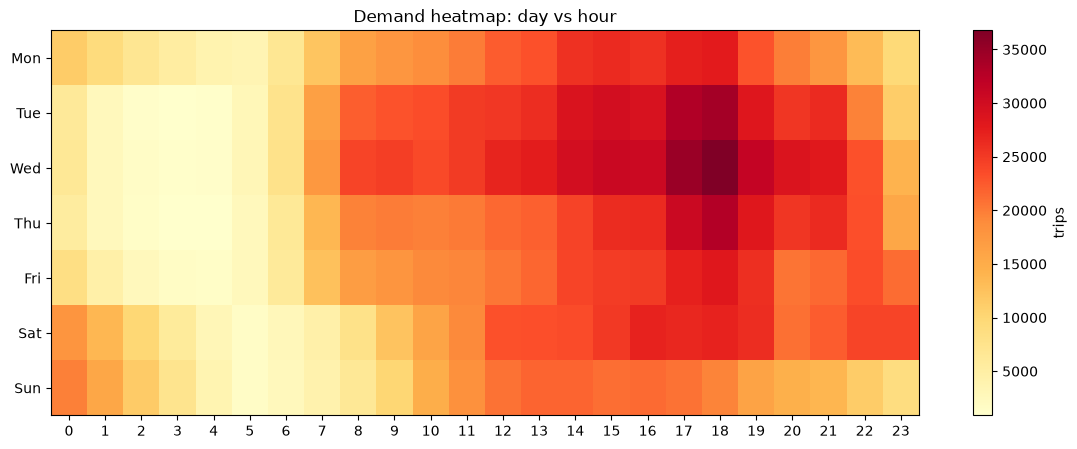

In [52]:
import numpy as np

pivot = df.groupby(["pickup_dow", "pickup_hour"]).size().unstack()
pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(14, 5))
plt.imshow(pivot, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="trips")
plt.xticks(range(24), range(24))
plt.yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("Demand heatmap: day vs hour")
plt.show()


In [54]:
top_zones = df.groupby("PULocationID").size().sort_values(ascending=False).head(20)
print(top_zones)


PULocationID
161    140140
237    140120
132    138450
236    133961
162    104345
230    102958
186    102152
142    101794
138     87694
239     86468
163     83677
170     80954
68      75545
234     74373
48      74074
141     72163
249     64281
140     64197
79      63601
164     63076
dtype: int64
